### Глобальный набор данных обзоров мобильных устройств (издание 2025 г.)
Комплексный исследовательский набор данных из более чем 50 000 отзывов о мобильных телефонах от пользователей со всего мира

#### О наборе данных
📱 Глобальный набор данных по отзывам о мобильных устройствах (издание 2025 г.)
🌍 Коллекция глобальных обзоров, основанная на исследованиях и собранная из веб-страниц
Этот набор данных представляет собой тщательно подобранную коллекцию из более чем 50 000 обзоров мобильных телефонов, собранных посредством веб-скрапинга, анализа рынка и агрегации контента с различных платформ электронной коммерции и обзоров технологий .
Он охватывает восемь стран и включает подробные данные о мнениях пользователей, рейтингах, полярности настроений и ценах ведущих брендов смартфонов.

Каждая запись отражает целостный опыт клиента — охватывает демографические данные, подтвержденные сведения о покупках, многоаспектные рейтинги и цены с поправкой на валюту, — что делает этот набор данных мощным активом для исследований, обработки естественного языка и аналитики.

Идеально подходит для:
* Анализ настроений и моделирование НЛП
* Классификация текстов и анализ обзоров
* Маркетинговые исследования и аналитика цен
* Исследования поведения потребителей
* Проекты по обучению моделей ИИ и анализу данных

#### Ключевые моменты
* Более 50 000 обзоров мобильных устройств, собранных из ведущих мировых источников
* Обзоры в 8 основных странах и на нескольких платформах
* Демографические данные (имя клиента, возраст, местоположение)
* Проверенные флаги покупки для обеспечения надежности
* Подробные субрейтинги на уровне продукта
* Цены указаны в долларах США и местной валюте.
* Поддержка многоязычных данных и распределение настроений по странам
* Профессионально очищен и нормализован для исследовательских целей



In [2]:
import pandas as pd
import numpy as np

In [3]:
import bz2 
from utils.baseline import *

In [4]:
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
#from sklearn.feature_selection import 
#from sklearn.preprocessing import 
from sklearn.metrics import accuracy_score, classification_report

In [18]:
from matplotlib import pyplot as plt
import seaborn as sns

In [ ]:
pd.set_option('display.max_columns', None)


### 1. Загрузка данных

In [5]:
data = pd.read_csv('./data/Mobile Reviews Sentiment.csv')

In [120]:
data.head(5)

,review_id,customer_name,age,brand,model,price_usd,price_local,currency,exchange_rate_to_usd,rating,review_text,sentiment,country,language,review_date,verified_purchase,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,review_length,word_count,helpful_votes,source
0,1,Aryan Maharaj,45,Realme,Realme 12 Pro,337.31,₹27996.73,INR,83.00,2,Not worth the money spent. Wouldn’t recommend.,Negative,India,Hindi,2023-11-06,True,1,1,3,2,1,46,7,1,Amazon
1,2,Davi Miguel Sousa,18,Realme,Realme 12 Pro,307.78,R$1754.35,BRL,5.70,4,Absolutely love this phone! The camera is next...,Positive,Brazil,Portuguese,2023-03-30,True,3,2,4,3,2,74,12,5,Flipkart
2,3,Pahal Balay,27,Google,Pixel 6,864.53,₹71755.99,INR,83.00,4,Loving the clean UI and fast updates. Loving i...,Positive,India,Hindi,2022-12-07,True,3,5,3,2,4,55,11,8,AliExpress
3,4,David Guzman,19,Xiaomi,Redmi Note 13,660.94,د.إ2425.65,AED,3.67,3,Build quality feels solid and durable. No regr...,Positive,UAE,English,2025-03-11,False,1,3,2,1,2,66,11,3,Amazon
4,5,Yago Leão,38,Motorola,Edge 50,792.13,R$4515.14,BRL,5.70,3,Not bad for daily use but could be optimized. ...,Neutral,Brazil,Portuguese,2023-09-29,True,3,3,2,2,1,73,12,0,BestBuy


In [121]:
data.tail(5)

,review_id,customer_name,age,brand,model,price_usd,price_local,currency,exchange_rate_to_usd,rating,review_text,sentiment,country,language,review_date,verified_purchase,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,review_length,word_count,helpful_votes,source
49995,49996,Rebecca Pratt,18,Realme,Realme 12 Pro,526.10,A$804.93,AUD,1.53,4,Battery easily lasts a day with heavy use. Lov...,Positive,Australia,English,2023-08-17,False,3,3,4,3,5,60,12,4,BestBuy
49996,49997,Dr. Tiffany Patterson,28,Samsung,Galaxy Note 20,911.85,A$1395.13,AUD,1.53,3,Battery life could be slightly better. Fine bu...,Neutral,Australia,English,2023-09-23,False,3,2,4,1,3,64,11,2,AliExpress
49997,49998,Alexandra Singh,21,Apple,iPhone SE,1155.32,د.إ4240.02,AED,3.67,5,"Face unlock is instant, super smooth. Best pur...",Positive,UAE,English,2023-04-04,True,2,3,4,4,5,64,11,4,Amazon
49998,49999,Robert Morris,31,Realme,Realme Narzo 70,459.04,$459.04,USD,1.00,3,Build quality feels solid and durable. Loving ...,Positive,USA,English,2025-07-11,True,1,2,2,1,3,56,10,6,AliExpress
49999,50000,Regina Dennis MD,44,Motorola,Moto G Power,380.16,$380.16,USD,1.00,5,Loving the clean UI and fast updates. Loving i...,Positive,USA,English,2024-11-26,True,4,5,4,5,3,55,11,7,BestBuy


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   review_id             50000 non-null  int64  
 1   customer_name         50000 non-null  object 
 2   age                   50000 non-null  int64  
 3   brand                 50000 non-null  object 
 4   model                 50000 non-null  object 
 5   price_usd             50000 non-null  float64
 6   price_local           50000 non-null  object 
 7   currency              50000 non-null  object 
 8   exchange_rate_to_usd  50000 non-null  float64
 9   rating                50000 non-null  int64  
 10  review_text           50000 non-null  object 
 11  sentiment             50000 non-null  object 
 12  country               50000 non-null  object 
 13  language              50000 non-null  object 
 14  review_date           50000 non-null  object 
 15  verified_purchase  

| **column_name**          | **description**                                                                         |
| ------------------------ | --------------------------------------------------------------------------------------- |
| **review_id**            | Уникальный идентификатор отзыва.                                                        |
| **customer_name**        | Имя покупателя, оставившего отзыв.                                                      |
| **age**                  | Возраст покупателя, если указан.                                                        |
| **brand**                | Марка мобильного телефона (например, Apple, Samsung).                                   |
| **model**                | Модель мобильного телефона (например, Galaxy S23).                                      |
| **price_usd**            | Цена товара в долларах США.                                                             |
| **price_local**          | Локальная цена, возможно, в другой валюте (например, в рублях или евро).                |
| **currency**             | Валюта, в которой указана цена (например, USD, EUR).                                    |
| **exchange_rate_to_usd** | Курс обмена валюты на доллар США.                                                       |
| **rating**               | Оценка отзыва (обычно от 1 до 5).                                                       |
| **review_text**          | Текст отзыва пользователя о товаре.                                                     |
| **sentiment**            | Эмоциональная окраска отзыва, возможно, классификация на позитивный или негативный.     |
| **country**              | Страна, в которой был написан отзыв.                                                    |
| **language**             | Язык отзыва (например, английский, русский).                                            |
| **review_date**          | Дата публикации отзыва.                                                                 |
| **verified_purchase**    | Булево значение (True/False), указывающее, был ли товар реально приобретен покупателем. |
| **battery_life_rating**  | Оценка покупателя по продолжительности работы аккумулятора (от 1 до 5).                 |
| **camera_rating**        | Оценка качества камеры мобильного телефона (от 1 до 5).                                 |
| **performance_rating**   | Оценка производительности устройства (от 1 до 5).                                       |
| **design_rating**        | Оценка дизайна телефона (от 1 до 5).                                                    |
| **display_rating**       | Оценка экрана телефона (от 1 до 5).                                                     |
| **review_length**        | Длина отзыва (количество символов).                                                     |
| **word_count**           | Количество слов в отзыве.                                                               |
| **helpful_votes**        | Количество голосов за полезность отзыва.                                                |
| **source**               | Источник отзыва (например, веб-сайт или приложение, на котором был оставлен отзыв).     |


#### Применение этих данных в проекте:

* **Анализ тональности:** можно использовать `sentiment`, чтобы предсказать или улучшить модели тональности.

* **Рейтинг и оценка:** столбцы `rating` и категориальные рейтинги для различных характеристик телефона (например, `battery_life_rating`, `camera_rating`) можно использовать для многоклассовой классификации.

* **Отчёты по брендам:** можно анализировать отзывы по брендам (столбцы `brand`, `model`), чтобы выявить, какие модели получают наибольшее количество положительных или отрицательных отзывов.

* **Отзывы и полезность:** столбцы `helpful_votes`, `review_length` и `word_count` можно использовать для анализа, какие факторы влияют на восприятие отзыва другими пользователями.

### 2. Разведочный анализ данных (EDA)

#### 2.1. Проверка на дубликаты

In [13]:
print(f'Количество дубликатов: {data.duplicated().sum()}')

Количество дубликатов: 0


In [128]:
drop_col = [col for col in data.columns if col not in ['review_id', 'customer_name']]

In [129]:
data[drop_col].duplicated().sum()

0

#### 2.2. Проверка на пропущенные значения

In [14]:
data.isna().sum()

review_id               0
customer_name           0
age                     0
brand                   0
model                   0
price_usd               0
price_local             0
currency                0
exchange_rate_to_usd    0
rating                  0
review_text             0
sentiment               0
country                 0
language                0
review_date             0
verified_purchase       0
battery_life_rating     0
camera_rating           0
performance_rating      0
design_rating           0
display_rating          0
review_length           0
word_count              0
helpful_votes           0
source                  0
dtype: int64

#### 2.3. Проверка на вменяемость фичей

`Age`

C:\Users\46120\AppData\Local\Temp\ipykernel_26572\3629117760.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data['age'].value_counts().index, y=data['age'].value_counts().values, palette='coolwarm', alpha=1, ax=ax[0]);


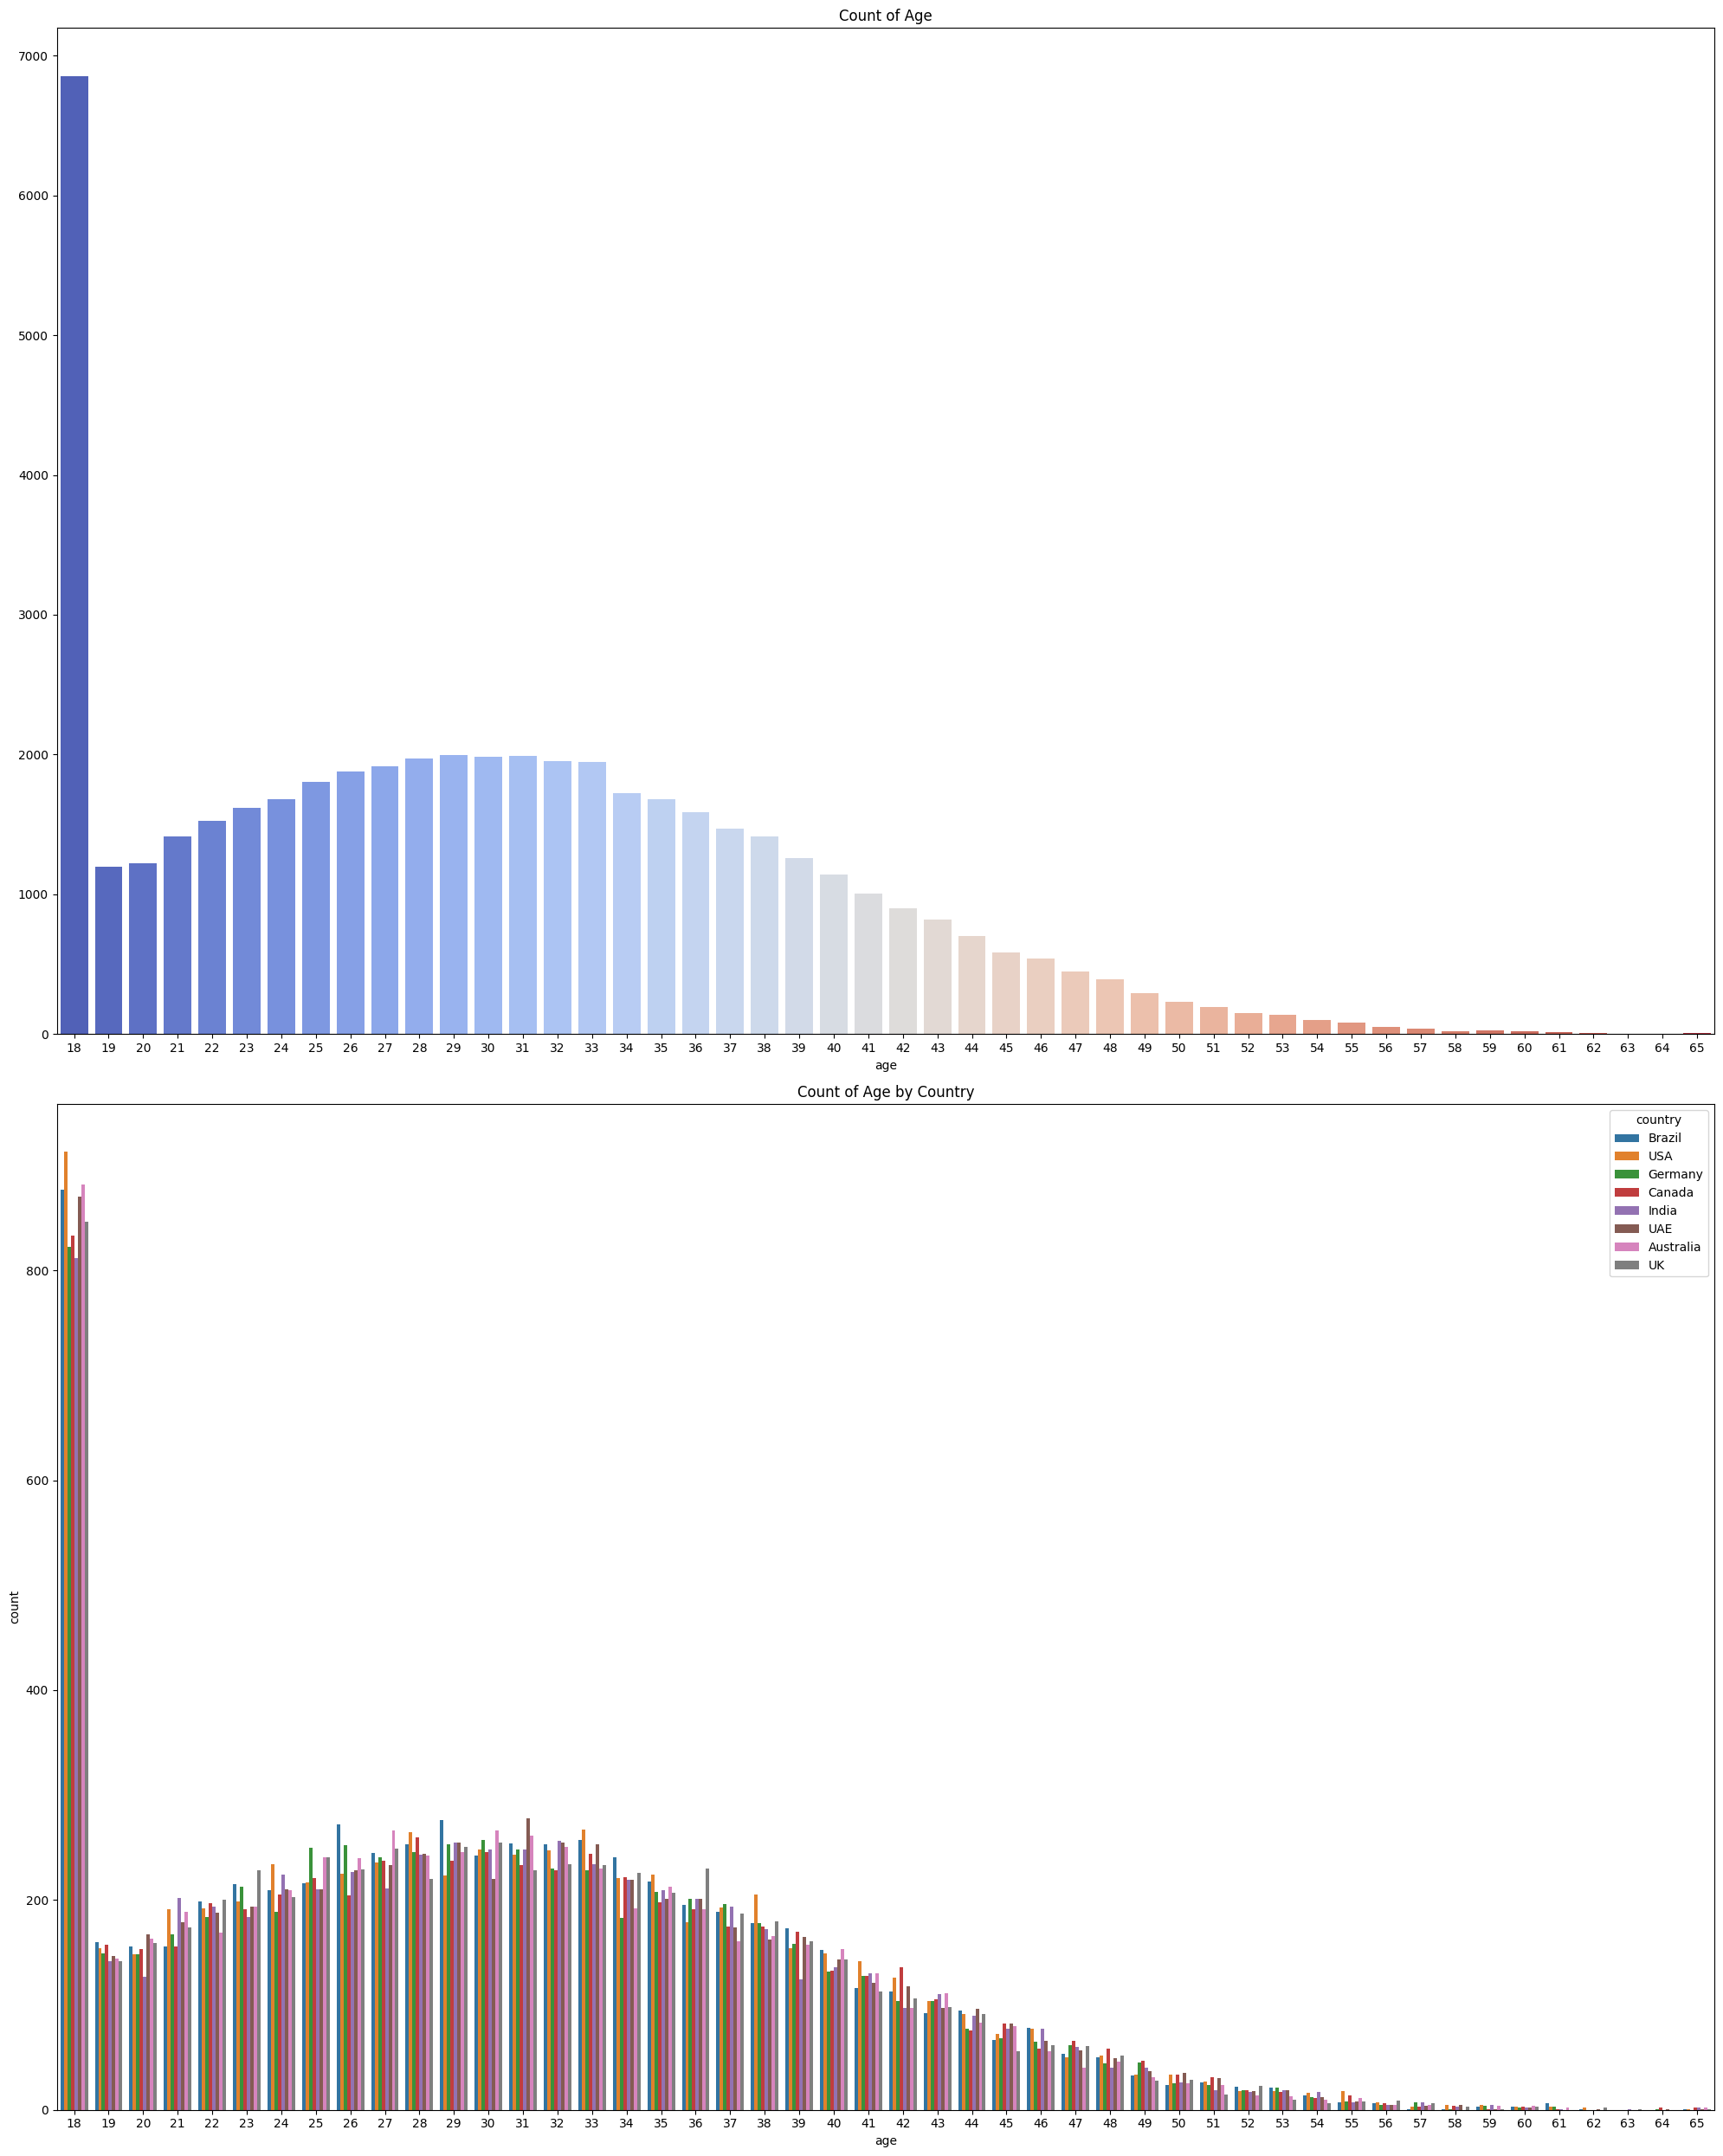

In [104]:
fig, ax = plt.subplots(2, 1, figsize=(20, 25))

sns.barplot(x=data['age'].value_counts().index, y=data['age'].value_counts().values, palette='coolwarm', alpha=1, ax=ax[0]);
ax[0].set_title(f'Count of Age');

sns.countplot(x='age', hue='country', data=data, ax=ax[1])
ax[1].set_title(f'Count of Age by Country');
#ax[1].grid(True)

plt.tight_layout()
plt.show()

`Brand`/`Model`

C:\Users\46120\AppData\Local\Temp\ipykernel_26572\2501579825.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data['brand'].value_counts(), alpha=1, palette='pastel', ax=ax[0]);


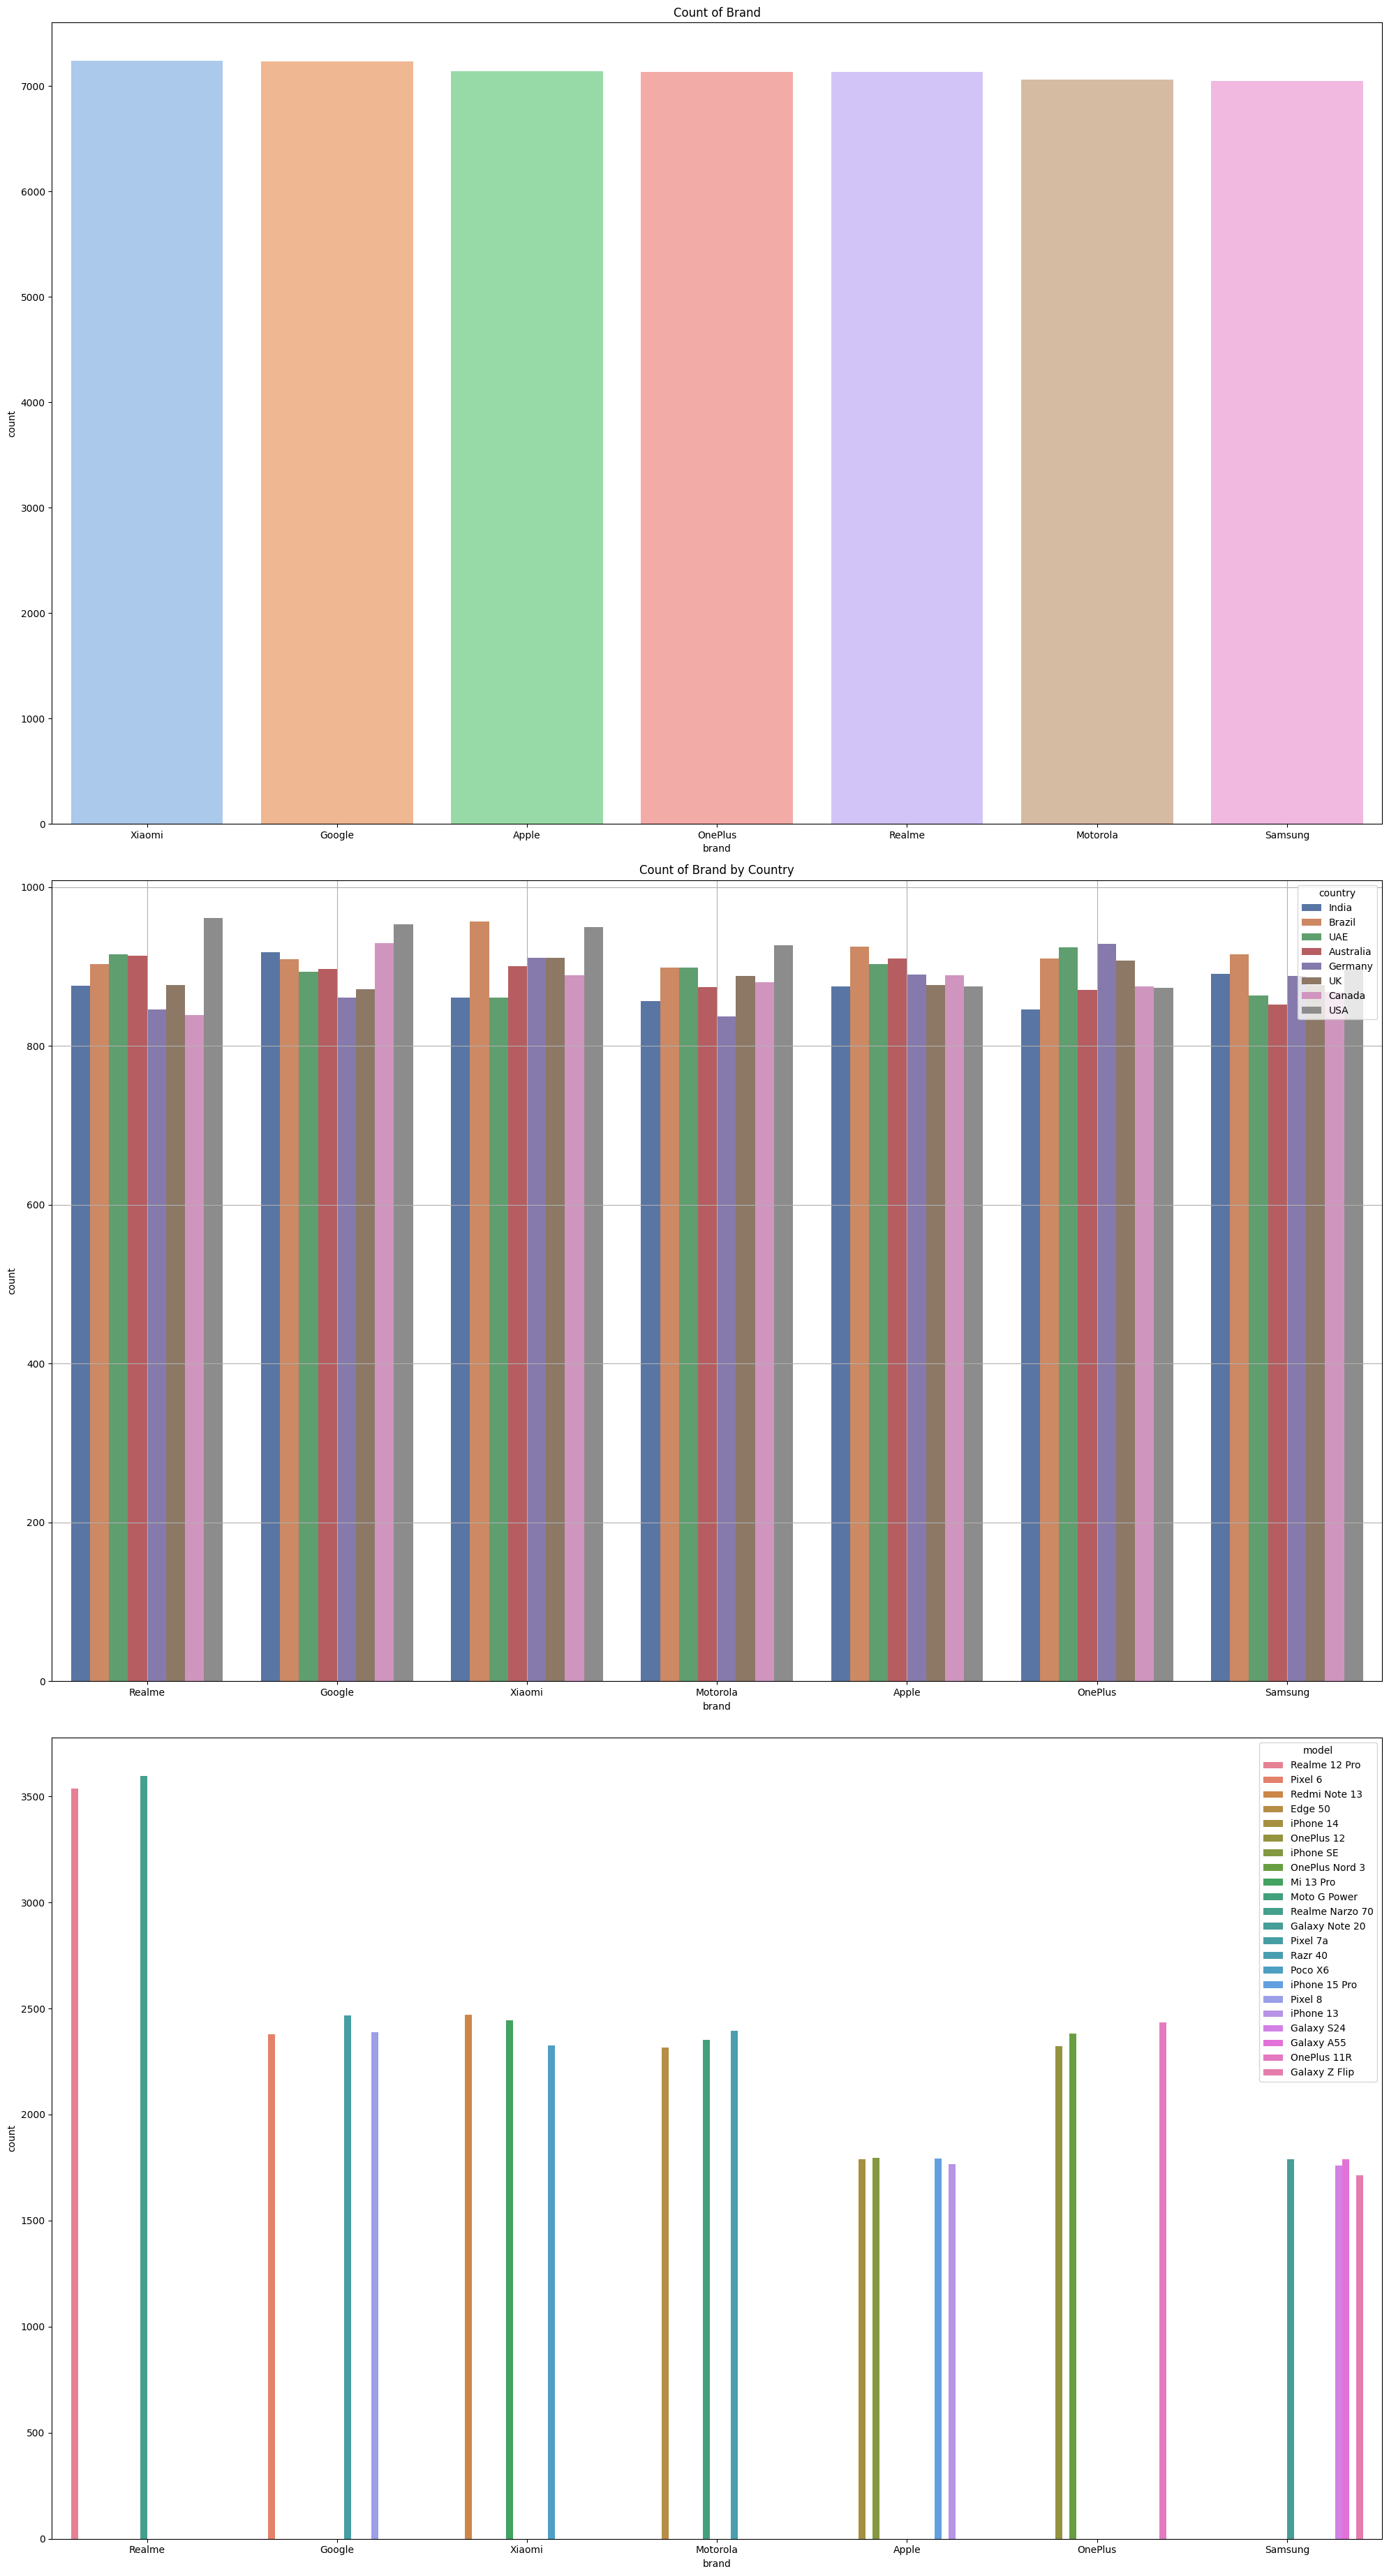

In [112]:
fig, ax = plt.subplots(3, 1, figsize=(20, 37))

sns.barplot(data['brand'].value_counts(), alpha=1, palette='pastel', ax=ax[0]);
ax[0].set_title(f'Count of Brand');

sns.countplot(x='brand', hue='country', data=data, palette='deep', ax=ax[1])
ax[1].set_title(f'Count of Brand by Country');
ax[1].grid(True)


sns.countplot(data=data, x='brand', hue='model', alpha=1, ax=ax[2]);

plt.tight_layout()
plt.show()

In [122]:
data['price_usd'].value_counts()

price_usd
559.68     6
484.07     6
412.20     6
577.62     5
552.96     5
          ..
754.37     1
1228.52    1
550.23     1
864.13     1
380.16     1
Name: count, Length: 39893, dtype: int64

In [115]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   review_id             50000 non-null  int64  
 1   customer_name         50000 non-null  object 
 2   age                   50000 non-null  int64  
 3   brand                 50000 non-null  object 
 4   model                 50000 non-null  object 
 5   price_usd             50000 non-null  float64
 6   price_local           50000 non-null  object 
 7   currency              50000 non-null  object 
 8   exchange_rate_to_usd  50000 non-null  float64
 9   rating                50000 non-null  int64  
 10  review_text           50000 non-null  object 
 11  sentiment             50000 non-null  object 
 12  country               50000 non-null  object 
 13  language              50000 non-null  object 
 14  review_date           50000 non-null  object 
 15  verified_purchase  

In [10]:
data['sentiment']

0        Negative
1        Positive
2        Positive
3        Positive
4         Neutral
           ...   
49995    Positive
49996     Neutral
49997    Positive
49998    Positive
49999    Positive
Name: sentiment, Length: 50000, dtype: object

In [5]:
data = train.copy()

In [6]:
data = pd.DataFrame(data, columns=['Text'])

In [7]:
prep = PreprocessingText()

In [8]:
data['Label'] = data['Text'].apply(prep.extract_label)         # записываем метки в Label
data['Text'] = data['Text'].apply(prep.drop_label_in_text)     # удаляем метку из текста
data['Text_Clean'] = data['Text'].apply(prep.clean_text)       # очистка текста

In [9]:
data['Label'] = data['Label'].map({1 : 0, 2 : 1})

In [10]:
data['Label'].value_counts()

Label
1    1800000
0    1800000
Name: count, dtype: int64

In [11]:
data.head(5)

,Text,Label,Text_Clean
0,Stuning even for the non-gamer: This sound tr...,1,stuning even for the non gamer this sound trac...
1,The best soundtrack ever to anything.: I'm re...,1,the best soundtrack ever to anything i m readi...
2,Amazing!: This soundtrack is my favorite musi...,1,amazing this soundtrack is my favorite music o...
3,Excellent Soundtrack: I truly like this sound...,1,excellent soundtrack i truly like this soundtr...
4,"Remember, Pull Your Jaw Off The Floor After H...",1,remember pull your jaw off the floor after hea...


In [12]:
X = data['Text_Clean']
y = data['Label']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

In [13]:
count_pipe = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('clf', LogisticRegression())
]) 

count_pipe.fit(X_train, y_train)

pred = count_pipe.predict(X_val)
acc = classification_report(y_val, pred)

print(acc)

c:\Users\46120\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

           0       0.91      0.90      0.91    359759
           1       0.90      0.91      0.91    360241

    accuracy                           0.91    720000
   macro avg       0.91      0.91      0.91    720000
weighted avg       0.91      0.91      0.91    720000



In [14]:
a

NameError: name 'a' is not defined

In [ ]:
tf_pipe = Pipeline([
    ('vectorizer', TfidfVectorizer()),
    ('clf', LogisticRegression())
]) 

tf_pipe.fit(X_train, y_train)

pred = tf_pipe.predict(X_val)
acc = classification_report(y_val, pred)

print(acc)

c:\Users\46120\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

           0       0.91      0.91      0.91    359759
           1       0.91      0.91      0.91    360241

    accuracy                           0.91    720000
   macro avg       0.91      0.91      0.91    720000
weighted avg       0.91      0.91      0.91    720000

